In [2]:
import pandas
import numpy as np
import matplotlib.pyplot as plt


In [3]:
data = pandas.read_csv(
    "https://raw.githubusercontent.com/orrymr/ass1_q2_lwlr/master/data/x.dat",
    header=None,
    sep=r'\s+',
    names=["var1", "var2"]
)
labels = pandas.read_csv("https://raw.githubusercontent.com/orrymr/ass1_q2_lwlr/master/data/y.dat"
                         , header=None, names=["outcome"])
all_data = pandas.concat([data, labels], axis = 1, names = ["var1", "var2", "outcome"])


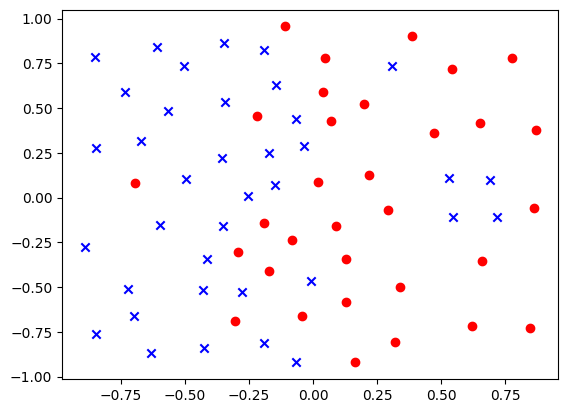

In [4]:
negative = all_data[all_data.outcome == 0]
positive = all_data[all_data.outcome == 1]
plt.scatter(negative.var1, negative.var2, c = 'b', marker = 'x')
plt.scatter(positive.var1, positive.var2, c = 'r', marker = 'o')

In [73]:
LAMBDA = 0.0001
tau = 1

def sigmoid(z):
    
    return 1 / (1 + np.e**(-z)) 

def hypothesis(theta, x):
    return np.clip(sigmoid(np.dot(x, theta)), -1e16, 1e16)


def getWeights(data, new_point, tau):
    assert (new_point.shape[0] == 1) #new point should be 1xn, where n is the number of features
    new_point_repeat = np.repeat(new_point, data.shape[0], axis = 0) #for a 2-D array, axis=0 == rows, axis=1 == columns    
    norm_squared = np.linalg.norm(data - new_point_repeat, axis = 1) ** 2
    weights = np.exp(-norm_squared / (2 * tau ** 2))
    return weights.reshape(len(weights), 1)
    
def lwlr(x_train, y_train, x, tau):
    
    #generate ones in x for constant term
    x_train_aug = pandas.concat([pandas.Series(np.ones(len(x_train.index))), x_train], axis = 1)
    x_aug = np.concatenate([np.asarray([[1]]), x], axis = 1)
    
    #Same for theta (extra term, all zeros at t=0)
    theta_length = x_train_aug.shape[1] 
    theta = np.zeros([theta_length, 1]) 
    dist = 1
   
    while np.max(np.abs(dist)) > 1e-6:
        #get weights
        weights = getWeights(x_train_aug, x_aug, tau)
        #derivative
        z = weights * (y_train - hypothesis(theta, x_train_aug))
        deriv = np.dot(x_train_aug.transpose(), z) - LAMBDA * theta

        #hessian
        diags = -weights * hypothesis(theta, x_aug) * (1 - hypothesis(theta, x_aug))
        D = np.diag(diags[:, 0])
        H = np.dot(np.dot(x_train_aug.transpose(), D), x_train_aug) - LAMBDA * np.eye(x_train_aug.shape[1])

        theta_new = theta - np.linalg.inv(H) @ deriv
        
        dist = np.linalg.norm(theta_new - theta)
        
        theta = theta_new
    
    return theta

In [86]:
w = lwlr(data, labels,  data[0:1], tau)
w = w[:2]

print(w)
print(hypothesis(w ,data[0:1]))

[[0.08110435]
 [3.1934376 ]]
[[0.938564]]


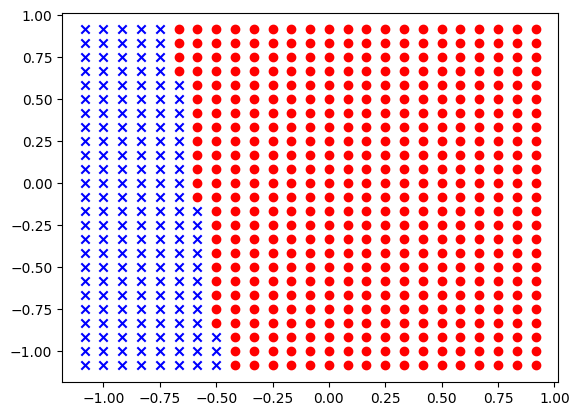

In [110]:
    res =25
    
    pred = np.ones(shape = (res, res))

    x = np.zeros((1, 2))
    for i in range(res):
        
        for j in range(res):
            x[0,0] = (2*(i-1)/float(res-1)) - 1
            x[0,1] = (2*(j-1)/float(res-1)) - 1
            final_theta = z #lwlr(data, labels, -x, tau)
            x_aug = np.concatenate([np.asarray([[1]]), x], axis = 1)
            pred[i,j] = hypothesis(final_theta, x_aug).item()
            
            if pred[i][j] < 0.5:
                plt.scatter(x[0][0], x[0][1], c = 'b', marker = 'x')
            elif pred[i][j] > 0.5:
                plt.scatter(x[0][0], x[0][1], c = 'r', marker = 'o')
    
    pred_negative = pred[pred == 0]
    pred_positive = pred[pred == 1]


In [109]:
x = np.zeros((1, 2))
z=lwlr(data, labels, x, 0.05)
print(sigmoid(x))


[[0.5 0.5]]


In [64]:
res=200
pred = np.empty(shape = (res, res))
x = np.zeros([1, 2])
x = np.zeros((1, 2))
print(data[4:5])
print(np.zeros((1, 2)))

       var1      var2
4 -0.352535 -0.160819
[[0. 0.]]


In [52]:
    res = 5
    pred = np.ones(shape = (res, res))
    print(pred)

[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]


In [72]:
hypothesis(final_theta, x_aug) 

array([[0.5, 0.5, 0.5]])